In [1]:
# Install required libraries
!pip install anndata scanpy

# Import libraries
import anndata as ad
import numpy as np
import pandas as pd
from scipy.sparse import csr_matrix
import scanpy as sc

print(f"AnnData version: {ad.__version__}")
print("All libraries imported successfully!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.6/176.6 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 40.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 38.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.7/295.7 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 31.5 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.
AnnData version: 0.12.10
All l

/tmp/ipykernel_15622/3877873260.py:11: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  print(f"AnnData version: {ad.__version__}")


In [2]:
# Create a basic AnnData object from scratch
counts = csr_matrix(np.random.poisson(1, size=(100, 2000)), dtype=np.float32)

# Create cell (observation) metadata
obs_meta = pd.DataFrame({
    "cell_type": np.random.choice(["T cell", "B cell", "NK cell", "Monocyte"], size=100),
    "sample": np.random.choice(["sample1", "sample2"], size=100),
    "total_counts": np.random.randint(500, 5000, size=100)
}, index=[f"cell_{i}" for i in range(100)])

# Create gene (variable) metadata
var_meta = pd.DataFrame({
    "gene_name": [f"gene_{i}" for i in range(2000)],
    "highly_variable": np.random.choice([True, False], size=2000)
}, index=[f"gene_{i}" for i in range(2000)])

# Create AnnData object
adata = ad.AnnData(X=counts, obs=obs_meta, var=var_meta)

print(adata)
print("\nCell types:", adata.obs["cell_type"].value_counts().to_dict())

AnnData object with n_obs × n_vars = 100 × 2000
    obs: 'cell_type', 'sample', 'total_counts'
    var: 'gene_name', 'highly_variable'

Cell types: {'Monocyte': 30, 'B cell': 27, 'NK cell': 22, 'T cell': 21}


In [3]:
# Add multiple data layers
adata.layers["counts"] = adata.X.copy()
adata.layers["normalized"] = adata.X.copy()

# Add unstructured metadata
adata.uns["experiment"] = {
    "date": "2024",
    "organism": "human",
    "tissue": "bone marrow",
    "protocol": "10X Chromium"
}

# Add dimensionality reductions
adata.obsm["X_pca"] = np.random.normal(size=(100, 50))
adata.obsm["X_umap"] = np.random.normal(size=(100, 2))

# Add pairwise distances
adata.obsp["distances"] = csr_matrix(np.random.random(size=(100, 100)))

print(adata)
print("\nLayers:", list(adata.layers.keys()))
print("Uns keys:", list(adata.uns.keys()))
print("Obsm keys:", list(adata.obsm.keys()))

AnnData object with n_obs × n_vars = 100 × 2000
    obs: 'cell_type', 'sample', 'total_counts'
    var: 'gene_name', 'highly_variable'
    uns: 'experiment'
    obsm: 'X_pca', 'X_umap'
    layers: 'counts', 'normalized'
    obsp: 'distances'

Layers: ['counts', 'normalized']
Uns keys: ['experiment']
Obsm keys: ['X_pca', 'X_umap']


In [4]:
# Subset by cell type
tcells = adata[adata.obs["cell_type"] == "T cell"]
print(f"T cells: {tcells.n_obs} cells")

# Subset by sample
sample1 = adata[adata.obs["sample"] == "sample1"]
print(f"Sample 1: {sample1.n_obs} cells")

# Subset by highly variable genes
hvg = adata[:, adata.var["highly_variable"]]
print(f"Highly variable genes: {hvg.n_vars} genes")

# Subset both cells and genes
subset = adata[adata.obs["cell_type"] == "B cell",
               adata.var["highly_variable"]]
print(f"B cells with HVGs: {subset.n_obs} cells × {subset.n_vars} genes")

# Concatenate two subsets
combined = ad.concat([tcells, sample1])
print(f"Combined: {combined.n_obs} cells")

T cells: 21 cells
Sample 1: 45 cells
Highly variable genes: 976 genes
B cells with HVGs: 27 cells × 976 genes
Combined: 66 cells


/usr/local/lib/python3.12/dist-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [5]:
# Write to H5AD file
adata.write_h5ad("anndata_tutorial.h5ad")
print("Saved to anndata_tutorial.h5ad")

# Read back
adata_loaded = ad.read_h5ad("anndata_tutorial.h5ad")
print(f"Loaded: {adata_loaded.n_obs} cells × {adata_loaded.n_vars} genes")

# Write to CSV
adata.obs.to_csv("cell_metadata.csv")
adata.var.to_csv("gene_metadata.csv")
print("Metadata saved to CSV files!")

# Check file sizes
import os
for f in ["anndata_tutorial.h5ad", "cell_metadata.csv", "gene_metadata.csv"]:
    size = os.path.getsize(f) / 1024
    print(f"{f}: {size:.1f} KB")

Saved to anndata_tutorial.h5ad
Loaded: 100 cells × 2000 genes
Metadata saved to CSV files!
anndata_tutorial.h5ad: 3375.3 KB
cell_metadata.csv: 2.8 KB
gene_metadata.csv: 47.7 KB


Real dataset loaded!
AnnData object with n_obs × n_vars = 700 × 765
    obs: 'bulk_labels', 'n_genes', 'percent_mito', 'n_counts', 'S_score', 'G2M_score', 'phase', 'louvain'
    var: 'n_counts', 'means', 'dispersions', 'dispersions_norm', 'highly_variable'
    uns: 'bulk_labels_colors', 'louvain', 'louvain_colors', 'neighbors', 'pca', 'rank_genes_groups'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'


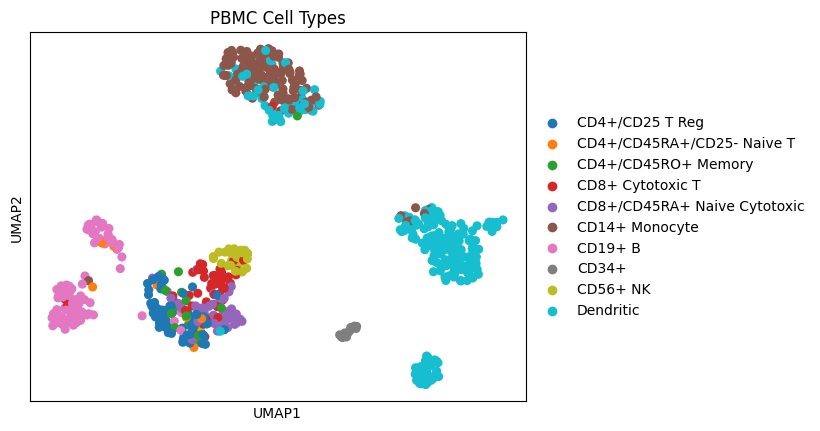

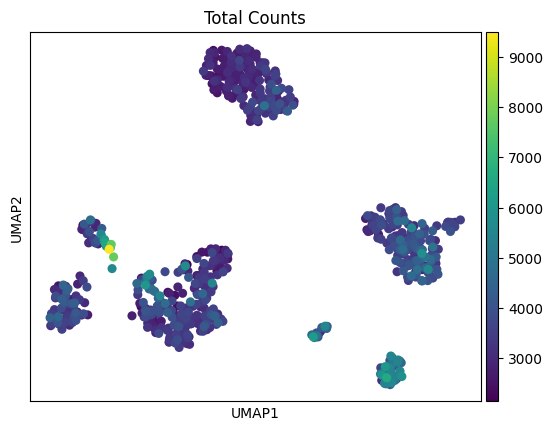


Cell types in dataset:
bulk_labels
Dendritic                       240
CD14+ Monocyte                  129
CD19+ B                          95
CD4+/CD25 T Reg                  68
CD8+ Cytotoxic T                 54
CD8+/CD45RA+ Naive Cytotoxic     43
CD56+ NK                         31
CD4+/CD45RO+ Memory              19
CD34+                            13
CD4+/CD45RA+/CD25- Naive T        8
Name: count, dtype: int64


In [6]:
# Load real PBMC dataset
adata_real = sc.datasets.pbmc68k_reduced()
print("Real dataset loaded!")
print(adata_real)

# Visualize
sc.pl.umap(adata_real, color=["bulk_labels"], title="PBMC Cell Types")
sc.pl.umap(adata_real, color=["n_counts"], title="Total Counts")

print("\nCell types in dataset:")
print(adata_real.obs["bulk_labels"].value_counts())

=== AnnData Structure ===
Shape: (700, 765)
Obs columns: ['bulk_labels', 'n_genes', 'percent_mito', 'n_counts', 'S_score', 'G2M_score', 'phase', 'louvain']
Var columns: ['n_counts', 'means', 'dispersions', 'dispersions_norm', 'highly_variable']
Obsm keys: ['X_pca', 'X_umap']
Uns keys: ['bulk_labels_colors', 'louvain', 'louvain_colors', 'neighbors', 'pca', 'rank_genes_groups']

T cells: 130
Non T cells: 570


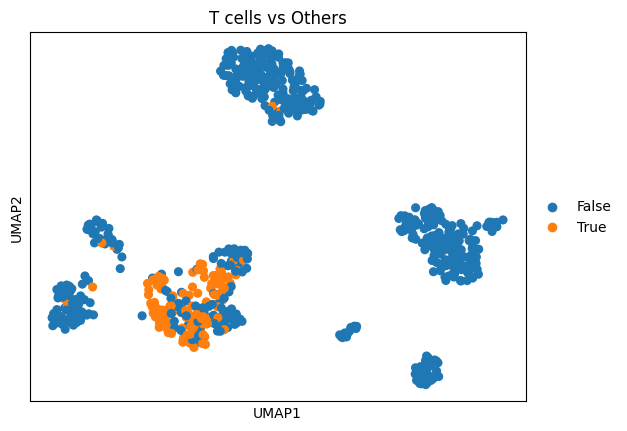


Final annotated data saved!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [7]:
# Inspect AnnData structure in detail
print("=== AnnData Structure ===")
print(f"Shape: {adata_real.shape}")
print(f"Obs columns: {list(adata_real.obs.columns)}")
print(f"Var columns: {list(adata_real.var.columns)}")
print(f"Obsm keys: {list(adata_real.obsm.keys())}")
print(f"Uns keys: {list(adata_real.uns.keys())}")

# Add new annotation
adata_real.obs["is_tcell"] = adata_real.obs["bulk_labels"].str.contains("T")
print(f"\nT cells: {adata_real.obs['is_tcell'].sum()}")
print(f"Non T cells: {(~adata_real.obs['is_tcell']).sum()}")

# Visualize new annotation
sc.pl.umap(adata_real, color=["is_tcell"], title="T cells vs Others")

# Save final object
adata_real.write_h5ad("pbmc_annotated.h5ad")
print("\nFinal annotated data saved!")

# Download files
from google.colab import files
files.download("anndata_tutorial.h5ad")
files.download("cell_metadata.csv")
files.download("gene_metadata.csv")